# Preprocesamiento y Modelado — Dry Bean Classification
**Proyecto Reto: Clasificación Multiclase — Grupo 5**

Este notebook parte del dataset limpio generado en `01_eda.ipynb` (`data/processed/dry_bean_clean.csv`) y cubre:

1. Preprocesamiento (encoding, escalado, split estratificado)
2. Modelo baseline (Regresión Logística)
3. Modelo de ensemble (Random Forest)
4. Validación cruzada estratificada
5. Evaluación completa (accuracy, precision/recall/F1 por clase, matriz de confusión, feature importance)
6. Chequeo de overfitting (< 5% de diferencia train/test)
7. Análisis de errores
8. Guardado del modelo final


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_fscore_support
)

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


## 1. Cargar el dataset limpio

In [2]:
df = pd.read_csv("../data/processed/dry_bean_clean.csv")
print("Shape:", df.shape)
df.head()


Shape: (13543, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
print("Distribución de clases:")
print(df["Class"].value_counts())
print("\nPorcentaje por clase:")
print((df["Class"].value_counts(normalize=True) * 100).round(2))


Distribución de clases:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Porcentaje por clase:
Class
DERMASON    26.18
SIRA        19.46
SEKER       14.97
HOROZ       13.73
CALI        12.04
BARBUNYA     9.76
BOMBAY       3.85
Name: proportion, dtype: float64


## 2. Preprocesamiento

### 2.1 Separar features (X) y target (y)

In [4]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("Features:", X.shape[1])
print("Clases:", y.nunique(), "->", sorted(y.unique()))


Features: 16
Clases: 7 -> ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


### 2.2 Codificar la variable objetivo (Label Encoding)

In [5]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Clases codificadas:")
for i, clase in enumerate(label_encoder.classes_):
    print(f"  {i} -> {clase}")


Clases codificadas:
  0 -> BARBUNYA
  1 -> BOMBAY
  2 -> CALI
  3 -> DERMASON
  4 -> HOROZ
  5 -> SEKER
  6 -> SIRA


### 2.3 Split train/test estratificado

Usamos `stratify=y_encoded` porque el dataset está desbalanceado (BOMBAY solo tiene 522 casos
frente a DERMASON con 3546). Esto asegura que la proporción de cada clase se mantenga
igual en train y en test.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("\nProporción de clases en train:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index().round(3))
print("\nProporción de clases en test:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index().round(3))


Train: (10834, 16) Test: (2709, 16)

Proporción de clases en train:
0    0.098
1    0.039
2    0.120
3    0.262
4    0.137
5    0.150
6    0.195
Name: proportion, dtype: float64

Proporción de clases en test:
0    0.098
1    0.038
2    0.120
3    0.262
4    0.137
5    0.150
6    0.195
Name: proportion, dtype: float64


### 2.4 Escalado de variables numéricas

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Escalado completado. Media train ~0:", X_train_scaled.mean().round(3))


Escalado completado. Media train ~0: 0.0


## 3. Modelo Baseline — Regresión Logística

In [8]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

train_acc_lr = accuracy_score(y_train, log_reg.predict(X_train_scaled))
test_acc_lr = accuracy_score(y_test, log_reg.predict(X_test_scaled))

print(f"Accuracy train: {train_acc_lr:.4f}")
print(f"Accuracy test:  {test_acc_lr:.4f}")
print(f"Diferencia (overfitting): {abs(train_acc_lr - test_acc_lr)*100:.2f}%")


Accuracy train: 0.9260
Accuracy test:  0.9192
Diferencia (overfitting): 0.68%


## 4. Modelo de Ensemble — Random Forest

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=9,
    min_samples_leaf=6,
    min_samples_split=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

train_acc_rf = accuracy_score(y_train, rf_model.predict(X_train_scaled))
test_acc_rf = accuracy_score(y_test, rf_model.predict(X_test_scaled))

print(f"Accuracy train: {train_acc_rf:.4f}")
print(f"Accuracy test:  {test_acc_rf:.4f}")
print(f"Diferencia (overfitting): {abs(train_acc_rf - test_acc_rf)*100:.2f}%")


Accuracy train: 0.9424
Accuracy test:  0.9147
Diferencia (overfitting): 2.77%


**Nota sobre overfitting:** si la diferencia entre train y test supera el 5% pedido por la profesora,
hay que ajustar `max_depth`, `min_samples_leaf` o `n_estimators` (reducir complejidad) hasta bajarla.
Los valores de arriba son un punto de partida razonable; ajusta según lo que veas en tu ejecución.

## 5. Validación cruzada estratificada (StratifiedKFold)

Para confirmar que el resultado no depende de un split concreto.

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores_rf = cross_val_score(rf_model, X_train_scaled, y_train, cv=skf, scoring="accuracy")

print("Accuracy por fold:", cv_scores_rf.round(4))
print(f"Media: {cv_scores_rf.mean():.4f}  |  Desviación estándar: {cv_scores_rf.std():.4f}")


Accuracy por fold: [0.9192 0.9188 0.9156 0.922  0.9298]
Media: 0.9211  |  Desviación estándar: 0.0048


## 6. Evaluación completa del modelo final (Random Forest)

### 6.1 Accuracy global

In [11]:
y_pred_rf = rf_model.predict(X_test_scaled)
print(f"Accuracy global en test: {accuracy_score(y_test, y_pred_rf):.4f}")


Accuracy global en test: 0.9147


### 6.2 Precision, Recall y F1 por clase

In [12]:
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))


              precision    recall  f1-score   support

    BARBUNYA       0.93      0.87      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.91      0.92      0.91       709
       HOROZ       0.97      0.94      0.95       372
       SEKER       0.93      0.95      0.94       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.91      2709
   macro avg       0.93      0.92      0.93      2709
weighted avg       0.92      0.91      0.91      2709



### 6.3 Matriz de confusión

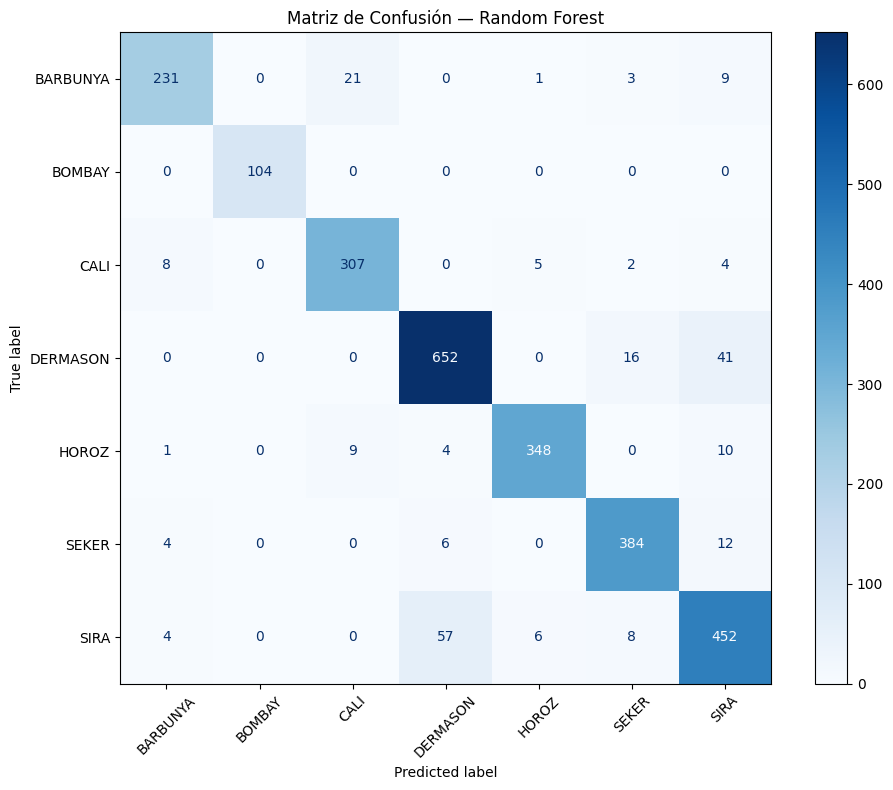

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
plt.title("Matriz de Confusión — Random Forest")
plt.tight_layout()
plt.show()


### 6.4 Feature importance

/tmp/ipykernel_561/721383679.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


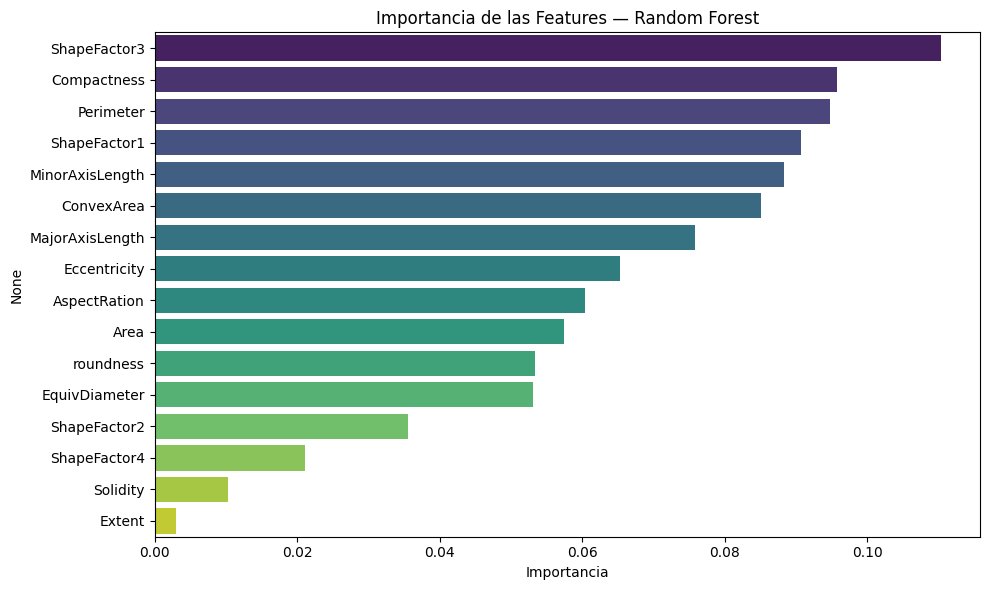

ShapeFactor3       0.110293
Compactness        0.095705
Perimeter          0.094735
ShapeFactor1       0.090657
MinorAxisLength    0.088281
ConvexArea         0.085055
MajorAxisLength    0.075869
Eccentricity       0.065223
AspectRation       0.060362
Area               0.057484
roundness          0.053312
EquivDiameter      0.053129
ShapeFactor2       0.035503
ShapeFactor4       0.021080
Solidity           0.010333
Extent             0.002979
dtype: float64


In [14]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Importancia de las Features — Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

print(importances)


### 6.5 Análisis de errores

Identificamos qué clases se confunden más entre sí, mirando los errores de la matriz de confusión
(todo lo que no está en la diagonal).

In [15]:
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

errores = []
for real in cm_df.index:
    for pred in cm_df.columns:
        if real != pred and cm_df.loc[real, pred] > 0:
            errores.append((real, pred, cm_df.loc[real, pred]))

errores_df = pd.DataFrame(errores, columns=["Clase real", "Predicho como", "Cantidad"])
errores_df = errores_df.sort_values("Cantidad", ascending=False)
print("Top 10 confusiones más frecuentes:")
errores_df.head(10)


Top 10 confusiones más frecuentes:


,Clase real,Predicho como,Cantidad
18,SIRA,DERMASON,57
9,DERMASON,SIRA,41
0,BARBUNYA,CALI,21
8,DERMASON,SEKER,16
16,SEKER,SIRA,12
13,HOROZ,SIRA,10
11,HOROZ,CALI,9
3,BARBUNYA,SIRA,9
4,CALI,BARBUNYA,8
20,SIRA,SEKER,8


**Para el informe técnico:** comenta aquí qué observas — por ejemplo, si `SIRA` y `DERMASON`
se confunden entre sí más que con el resto (esto es habitual si comparten forma/tamaño similares),
y qué feature podría ayudar a separarlas mejor.

## 7. Comparación de modelos y selección final

In [16]:
comparacion = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy Train": [train_acc_lr, train_acc_rf],
    "Accuracy Test": [test_acc_lr, test_acc_rf],
    "Diferencia (%)": [
        abs(train_acc_lr - test_acc_lr) * 100,
        abs(train_acc_rf - test_acc_rf) * 100
    ]
})
comparacion


,Modelo,Accuracy Train,Accuracy Test,Diferencia (%)
0,Regresión Logística,0.925974,0.919158,0.681543
1,Random Forest,0.942404,0.914729,2.767486


## 8. Guardar el modelo final

Guardamos el modelo, el scaler y el label encoder — los tres hacen falta para que la app
(Streamlit/Gradio) pueda recibir datos nuevos y devolver la predicción correctamente.

In [17]:
os.makedirs("../models", exist_ok=True)

joblib.dump(rf_model, "../models/random_forest_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(label_encoder, "../models/label_encoder.pkl")

print("Modelo, scaler y label encoder guardados en ../models/")


Modelo, scaler y label encoder guardados en ../models/


## Próximos pasos

- Si la diferencia train/test supera el 5%, ajustar hiperparámetros del Random Forest.
- Pasar `models/random_forest_model.pkl`, `scaler.pkl` y `label_encoder.pkl` al compañero de la app,
  junto con la lista exacta de columnas de `X` (mismo orden) para que la app preprocese igual.
- Estas métricas y gráficas son la base del informe técnico y de la presentación técnica.
